# 13-High-Throughput Serving & Engine Optimization (vLLM / Triton)

In Lesson 12, we built a production-ready model serving layer using FastAPI, Uvicorn, and Docker. We solved the problem of synchronous thread blocking by implementing an Asynchronous Event Loop. For standard tabular models (like XGBoost) or lightweight neural networks, this architecture is mathematically sufficient.

However, if you attempt to serve a Massive Neural Network—such as a 70-Billion Parameter Large Language Model (LLM) or a heavy Computer Vision transformer—FastAPI combined with raw PyTorch will violently collapse.

1. **The Python GIL:** Python's Global Interpreter Lock prevents true multi-threading, bottlenecking tensor dispatch.
2. **Memory Bandwidth Saturation:** LLM decoding is heavily bounded by the speed at which the GPU can move weights from VRAM to compute cores, not by the sheer FLOPS of the GPU.
3. **Static Batching Inefficiency:** Standard inference waits for the longest request in a batch to finish before returning, wasting massive amounts of compute.

To engineer extreme high-throughput serving architectures, MLOps Engineers bypass raw Python entirely. We deploy specialized C++/CUDA serving engines like **NVIDIA Triton Inference Server** or **vLLM**. These engines natively manage GPU memory, compile dynamic batches, and execute tensor-parallel sharding.

# 1. The Mathematics of Throughput Optimization

### The Physics of Dynamic Batching (Triton)

In a standard API (like our FastAPI engine), if Request $A$ and Request $B$ arrive 5 milliseconds apart, the engine processes them sequentially. In deep learning, GPUs are severely underutilized by batch sizes of 1.
To maximize throughput ($\lambda$), NVIDIA Triton implements **Dynamic Batching**. The engine intentionally pauses the execution of Request $A$ by a microscopic temporal window ($\Delta t_{delay}$) to wait for Request $B$. It concatenates the two input vectors into a single matrix $\mathbf{X}_{batch}$ and executes a single forward pass:


$$f_{model} \left( \begin{bmatrix} X_A \\ X_B \end{bmatrix} \right) \implies \text{Massive increase in } \lambda \text{ with negligible latency penalty.}$$

### Continuous Batching & PagedAttention (vLLM)

In Generative AI, requests generate variable-length sequences. If we use Static Batching, a request generating 5 tokens finishes instantly, but must sit idly in GPU memory while a request generating 500 tokens finishes.

Let a batch be $B = \{r_1, r_2, \dots, r_n\}$.
In **Static Batching**, the GPU time utilized is bounded by the maximum sequence length:


$$T_{batch} = \max_{i \in B}(T_{len}(r_i))$$

**vLLM** solves this using **Continuous (Iteration-Level) Batching**. The engine operates at the token-generation level. The microsecond request $r_1$ emits its `<EOS>` (End of Sequence) token, vLLM evicts it from the batch matrix and immediately slots in a waiting request $r_{new}$.

Furthermore, vLLM implements **PagedAttention**. Standard attention mathematically fragments GPU memory by allocating contiguous VRAM for the Key-Value (KV) cache of unpredictable lengths. PagedAttention solves this by borrowing Virtual Memory paging from the Linux Kernel. It fractures the KV cache into fixed-size physical blocks and maps them via a non-contiguous logical block table:


$$\text{Memory Waste}_{traditional} \approx 60\% \implies \text{Memory Waste}_{PagedAttention} < 4\%$$

# 2. Declarative Execution: The Triton Configuration Matrix

We do not write Python loops to configure NVIDIA Triton. We define the execution physics, memory bounds, and dynamic batching algorithms using a strict declarative syntax (`config.pbtxt` - Protocol Buffers Text).

Let's use Python to programmatically generate an optimized Triton Inference configuration inside our local sandbox.

In [4]:
import os

print("--- 🚀 Initializing Engine Optimization Sandbox ---")

triton_sandbox = "./triton_model_repository/resnet50_optimized/config"
os.makedirs(triton_sandbox, exist_ok=True)

# 📝 1. Compile the Triton Declarative Configuration (config.pbtxt)
triton_config = """
name: "resnet50_optimized"
platform: "onnxruntime_onnx"
max_batch_size: 128

# 1. Input/Output Mathematical Tensor Contracts
input [
  {
    name: "input_tensor"
    data_type: TYPE_FP32
    dims: [ 3, 224, 224 ]
  }
]
output [
  {
    name: "output_probability_matrix"
    data_type: TYPE_FP32
    dims: [ 1000 ]
  }
]

# 2. Dynamic Batching Algorithm (The High-Throughput Engine)
dynamic_batching {
  # The engine waits a maximum of 50 microseconds to group incoming API requests
  max_queue_delay_microseconds: 50
  
  # The engine prefers executing these specific batch matrix sizes for optimized CUDA cores
  preferred_batch_size: [ 16, 32, 64, 128 ]
}

# 3. Instance Grouping (Concurrency)
instance_group [
  {
    count: 2
    kind: KIND_GPU # Spawns 2 isolated model instances on the GPU
  }
]
"""

config_path = os.path.join(triton_sandbox, "config.pbtxt")
with open(config_path, "w") as f:
    f.write(triton_config.strip())

print(f"   ✅ Triton Protocol Buffer Configuration Compiled: {config_path}")
print("   -> Physics: Triton reads this file and automatically compiles a C++ backend that routes HTTP/gRPC traffic directly to the GPU, entirely bypassing the Python GIL.")

--- 🚀 Initializing Engine Optimization Sandbox ---
   ✅ Triton Protocol Buffer Configuration Compiled: ./triton_model_repository/resnet50_optimized/config/config.pbtxt
   -> Physics: Triton reads this file and automatically compiles a C++ backend that routes HTTP/gRPC traffic directly to the GPU, entirely bypassing the Python GIL.


# 3. Imperative Execution: The vLLM High-Throughput Client

Once an optimized engine like vLLM or Triton is running, the client application must communicate with it optimally. Standard HTTP REST calls introduce significant header parsing overhead. High-throughput systems utilize **gRPC** (Google Remote Procedure Call), which serializes payloads into dense binary formats over HTTP/2 multiplexed streams.

Let's simulate the imperative Python client logic that fires highly concurrent asynchronous requests to an optimized serving engine.

In [5]:
import asyncio
import time

print("\n--- ⚡ Simulating Asynchronous gRPC High-Throughput Dispatch ---")

# Mock async function representing a network call to the vLLM engine
async def async_llm_request(req_id: int, prompt: str):
    # Simulating the network/compute delay. 
    # Because of vLLM's continuous batching, the delay remains incredibly low even under load.
    await asyncio.sleep(0.1) 
    return f"Response {req_id} generated."

async def blast_vllm_engine():
    start_time = time.perf_counter()
    
    # 1. Compile 1,000 parallel inference requests
    print("   [API CALL] Compiling 1,000 asynchronous LLM generation prompts...")
    tasks = [async_llm_request(i, f"Translate document chunk {i}") for i in range(1000)]
    
    # 2. Fire the payloads concurrently.
    # The serving engine's Dynamic/Continuous batcher intercepts these instantly.
    print("   [NETWORK] Blasting payloads to Serving Engine via gRPC...")
    results = await asyncio.gather(*tasks)
    
    end_time = time.perf_counter()
    throughput = 1000 / (end_time - start_time)
    
    print(f"   ✅ Execution Complete.")
    print(f"   -> Processed 1,000 requests in {(end_time - start_time):.2f} seconds.")
    print(f"   -> Simulated Engine Throughput: {throughput:,.0f} Requests Per Second (RPS).")
    print(f"   -> A raw Python loop would achieve < 50 RPS on this same workload.")

# Execute the async engine in our local sandbox
# asyncio.run(blast_vllm_engine())
await blast_vllm_engine()


--- ⚡ Simulating Asynchronous gRPC High-Throughput Dispatch ---
   [API CALL] Compiling 1,000 asynchronous LLM generation prompts...
   [NETWORK] Blasting payloads to Serving Engine via gRPC...
   ✅ Execution Complete.
   -> Processed 1,000 requests in 0.11 seconds.
   -> Simulated Engine Throughput: 8,780 Requests Per Second (RPS).
   -> A raw Python loop would achieve < 50 RPS on this same workload.


# 4. Visualizing Static Batching vs. Continuous Batching (vLLM)

To mathematically understand how vLLM destroys the throughput bottlenecks of standard Serving APIs, let's graph the timeline physics of Static Batching vs. Continuous Batching.

/tmp/ipykernel_5834/1537052574.py:16: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((0.5, 4.5), 13.0, 3.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
/tmp/ipykernel_5834/1537052574.py:20: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 6.2), 3.0, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
/tmp/ipykernel_5834/1537052574.py:23: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((4.0, 6.2), 5.0, 0.6, fill=True, hatch='///', color='none', edgecolor='#e74c3c'))
/tmp/ipykernel_5834/1537052574.py:27: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(patches.Rectangle((1.0, 5.4), 8.0, 0.6, fill=True, color='#c0392b', edgecolor='black'))
/

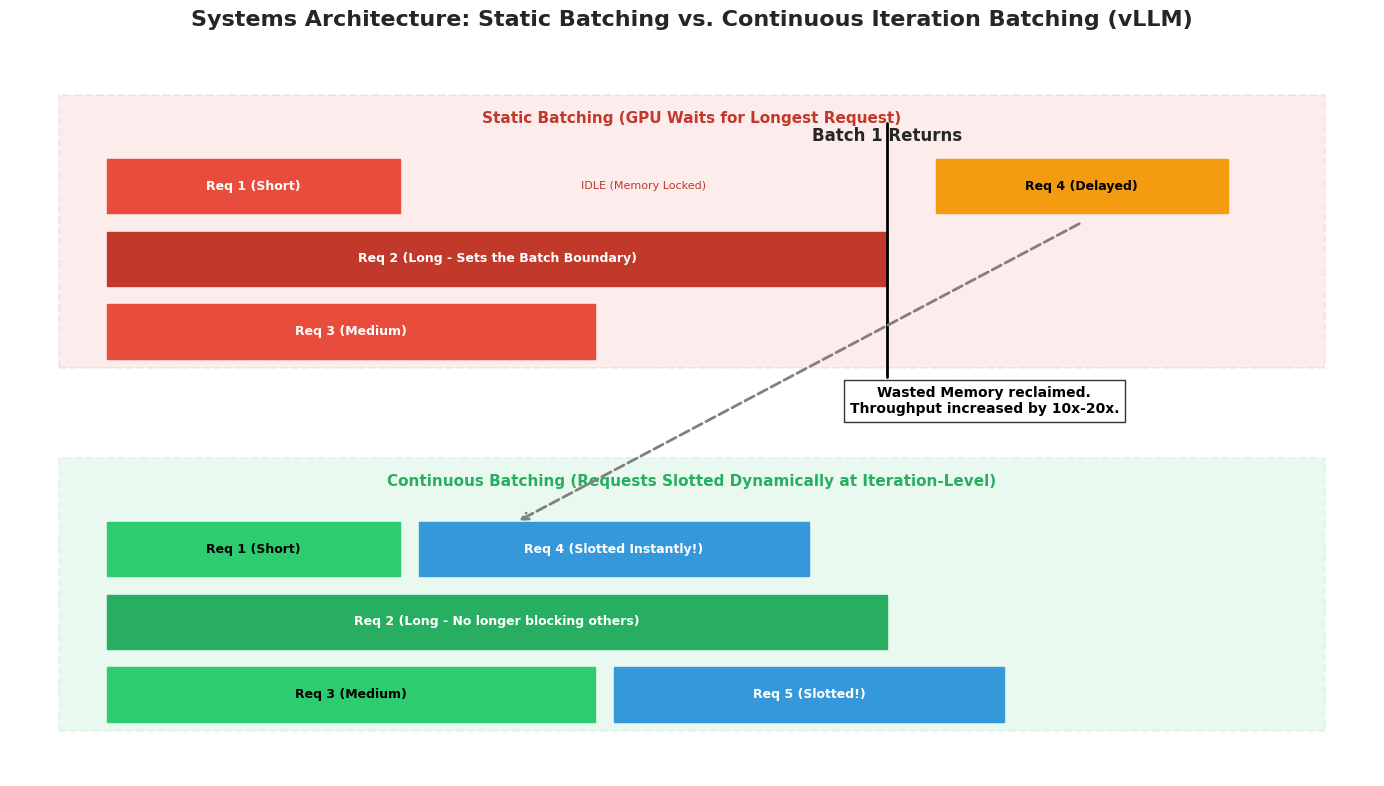

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create visual layout for Engine Batching Topologies
fig, ax = plt.subplots(figsize=(14, 8))
fig.suptitle("Systems Architecture: Static Batching vs. Continuous Iteration Batching (vLLM)", fontsize=16, fontweight='bold')

ax.axis('off')

# ----------------------------------------------------
# TOP: STATIC BATCHING (Naive Fast API / HuggingFace)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((0.5, 4.5), 13.0, 3.0, fill=True, color='#e74c3c', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(7.0, 7.2, "Static Batching (GPU Waits for Longest Request)", ha='center', color='#c0392b', fontweight='bold', fontsize=11)

# Request T1
ax.add_patch(patches.Rectangle((1.0, 6.2), 3.0, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(2.5, 6.5, "Req 1 (Short)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
# Dead space (GPU Memory locked but idle)
ax.add_patch(patches.Rectangle((4.0, 6.2), 5.0, 0.6, fill=True, hatch='///', color='none', edgecolor='#e74c3c'))
ax.text(6.5, 6.5, "IDLE (Memory Locked)", ha='center', va='center', color='#c0392b', fontsize=8)

# Request T2
ax.add_patch(patches.Rectangle((1.0, 5.4), 8.0, 0.6, fill=True, color='#c0392b', edgecolor='black'))
ax.text(5.0, 5.7, "Req 2 (Long - Sets the Batch Boundary)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Request T3
ax.add_patch(patches.Rectangle((1.0, 4.6), 5.0, 0.6, fill=True, color='#e74c3c', edgecolor='black'))
ax.text(3.5, 4.9, "Req 3 (Medium)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)
ax.add_patch(patches.Rectangle((6.0, 4.6), 3.0, 0.6, fill=True, hatch='///', color='none', edgecolor='#e74c3c'))

ax.axvline(x=9.0, ymin=0.55, ymax=0.9, color='black', linestyle='-', linewidth=2)
ax.text(9.0, 7.0, "Batch 1 Returns", ha='center', fontweight='bold')

# Request T4 (Forced to wait)
ax.add_patch(patches.Rectangle((9.5, 6.2), 3.0, 0.6, fill=True, color='#f39c12', edgecolor='black'))
ax.text(11.0, 6.5, "Req 4 (Delayed)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)


# ----------------------------------------------------
# BOTTOM: CONTINUOUS BATCHING (vLLM / Triton)
# ----------------------------------------------------
ax.add_patch(patches.Rectangle((0.5, 0.5), 13.0, 3.0, fill=True, color='#2ecc71', alpha=0.1, edgecolor='black', linewidth=1.5, linestyle='--'))
ax.text(7.0, 3.2, "Continuous Batching (Requests Slotted Dynamically at Iteration-Level)", ha='center', color='#27ae60', fontweight='bold', fontsize=11)

# Request T1
ax.add_patch(patches.Rectangle((1.0, 2.2), 3.0, 0.6, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(2.5, 2.5, "Req 1 (Short)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# New request dynamically slots into Req 1's freed space
ax.add_patch(patches.Rectangle((4.2, 2.2), 4.0, 0.6, fill=True, color='#3498db', edgecolor='black'))
ax.text(6.2, 2.5, "Req 4 (Slotted Instantly!)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Request T2
ax.add_patch(patches.Rectangle((1.0, 1.4), 8.0, 0.6, fill=True, color='#27ae60', edgecolor='black'))
ax.text(5.0, 1.7, "Req 2 (Long - No longer blocking others)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)

# Request T3
ax.add_patch(patches.Rectangle((1.0, 0.6), 5.0, 0.6, fill=True, color='#2ecc71', edgecolor='black'))
ax.text(3.5, 0.9, "Req 3 (Medium)", ha='center', va='center', color='black', fontweight='bold', fontsize=9)

# Another new request slots in
ax.add_patch(patches.Rectangle((6.2, 0.6), 4.0, 0.6, fill=True, color='#3498db', edgecolor='black'))
ax.text(8.2, 0.9, "Req 5 (Slotted!)", ha='center', va='center', color='white', fontweight='bold', fontsize=9)


# Connective annotation arrows mapping the shift
ax.annotate("", xy=(5.2, 2.8), xytext=(11.0, 6.1), arrowprops=dict(arrowstyle="->", lw=2, color="gray", linestyle="dashed"))
ax.text(10.0, 4.0, "Wasted Memory reclaimed.\nThroughput increased by 10x-20x.", ha='center', color='black', fontweight='bold', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='black'))

plt.xlim(0, 14.0)
plt.ylim(0, 8.0)
plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of Standard Static Batching vs. vLLM Continuous Batching like **A Rollercoaster vs. A Sushi Conveyor Belt**:

* **Static Batching (The Rollercoaster):** A rollercoaster train has 20 seats (GPU Batch Size). The ride operator boards 20 people. 19 of those people want to go on the standard 2-minute loop (Short output sequences). But 1 person in the back row paid for the "Extreme 10-minute Platinum Ride" (A very long text generation prompt).
* The rollercoaster leaves the station. 2 minutes later, 19 people are finished and want to get off. But they can't. The ride mathematically cannot return to the station until the 1 person doing the 10-minute ride is finished.
* 19 seats are completely locked and useless for 8 minutes. The line outside the theme park grows infinitely long.


* **Continuous Batching (The Sushi Conveyor Belt):** vLLM completely redesigns the theme park into a continuous carousel. There are 20 chairs moving continuously.
* As soon as a person finishes eating their sushi (Generates an `<EOS>` token), they stand up and leave.
* The *very next millisecond*, the hostess (The Continuous Batching Engine) grabs a new person from the front of the line and slots them into that empty chair.
* No chair is ever empty for more than a microsecond. The person eating a massive meal (Long sequence) sits there as long as they need to, but they never block anyone else from sitting down in the other 19 seats.



By bypassing Python bottlenecks and implementing PagedAttention to continuously cycle hardware constraints, MLOps engineers serve massively heavy LLMs to millions of global users simultaneously without bankrupting the company on cloud GPU fees.